# Dependências

In [2]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 59.7 MB/s eta 0:00:00


# Agrupamento de textos com K-Means

Neste notebook, usaremos o algoritmo k-means, um algoritmo simples e popular de agrupamento não-supervisionado, para agrupar letras de músicas de samba.

O objetivo do K-means é simples: agrupar pontos de dados semelhantes e descobrir padrões subjacentes. Para atingir esse objetivo, o K-means precisa de um número K de centróides em um conjunto de dados. Um centróide refere-se a um cluster, que é uma coleção de pontos de dados agregados devido a certas semelhanças entre si. As médias/means no K-means referem-se à média dos dados; isto é, encontrar o centróide. E o algoritmo é dito não supervisionado porque não temos conhecimento prévio sobre os grupos ou classes de nosso conjunto de dados, ou seja, encontraremos os grupos subjacentes em nosso conjunto de dados!

Abaixo podemos visualizar o algoritmo. Os centróides verdes correspondem aos pontos de dados mais próximos de cada um e formam clusters, então cada centróide se move para o centro de cada respectivo grupo e combina novamente os pontos de dados mais próximos entre si.

![alt text](https://github.com/lucas-de-sa/national-anthems-clustering/blob/master/Images/kmeans.gif?raw=true)

**Passos:**

__1.__ Explorar nossa coleção de músicas(corpus) <br>
__2.__ Aplicar engenharia de dados no conjunto de dados para obter o melhor desempenho do algoritmo K-means <br>
__3.__ Execute o algoritmo várias vezes, cada vez testando com um número diferente de clusters <br>
__4.__ Use diferentes métricas para visualizar nossos resultados e encontrar o melhor número de clusters (*ou seja, por que um total de X clusters é melhor do que um total de Y clusters?*) <br>
__5.__ Análise de cluster

**Métricas utilizadas para determinar o melhor número de K Cluters:**
- [Método do cotovelo](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html)
- [Silhouette Score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html)

## Importando bibliotecas

In [3]:
import pandas as pd
import numpy as np
import altair as alt

In [4]:
from sklearn import preprocessing, decomposition, model_selection, metrics, pipeline
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

import re
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans

from wordcloud import WordCloud
from sklearn.manifold import TSNE

from sklearn.feature_extraction.text import CountVectorizer
from gensim.models import Word2Vec

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# Algumas Funções úteis

In [5]:
def counting_words(df, predict, column):
  labels = np.unique(predict)
  couting = []
  for i in labels:
    mask = df[column] == i
    next_to_cluster = df[mask]
    a = next_to_cluster['clean_lyrics'].str.split()
    freq_word = []
    for i in a:
      freq_word = freq_word + i
    couting.append(nltk.FreqDist(freq_word))

  return couting

In [6]:
def generate_word_clouds(centroids):
    wordcloud = WordCloud(max_font_size=100, background_color = 'white')
    for i in range(0, len(centroids)):
        centroid_dict = centroids[i]
        wordcloud.generate_from_frequencies(centroid_dict)

        plt.figure()
        plt.title(f'Cluster {i}')
        plt.imshow(wordcloud)
        plt.axis("off")
        plt.show()

In [7]:
#Cálculo da PPMI
def compute_ppmi_smoothed(Xc, alpha=0.75):
    total = np.sum(Xc)
    sum_over_rows = np.sum(Xc, axis=1, keepdims=True)  # P(w)
    sum_over_cols = np.sum(Xc, axis=0, keepdims=True)  # P(c)

    # aplica suavização exponencial
    sum_over_rows_alpha = np.power(sum_over_rows, alpha)
    sum_over_cols_alpha = np.power(sum_over_cols, alpha)

    expected = sum_over_rows_alpha @ sum_over_cols_alpha / total
    with np.errstate(divide='ignore', invalid='ignore'):
        pmi = np.log2((Xc * total) / expected)
        pmi[np.isinf(pmi)] = 0.0
        pmi[np.isnan(pmi)] = 0.0
        pmi = np.maximum(pmi, 0)  # PPMI
    return pmi

## Analisando os dados

In [8]:
# Carregando um dataset de letras de músicas
letras = pd.read_csv('https://github.com/nazareno/palavras-nas-letras/raw/master/letras-ptbr-sample.csv')
#Subamostrando devido restrições de memória do colab
letras = letras.sample(1000, random_state=42)
letras.sample(10)

,SName,Lyric,Artist,Songs,Popularity,Genre,Genres
2314,Vento No Litoral,De tarde quero descansar. Chegar até a praia e...,Legião Urbana,118,27.7,Rock,Rock; Pop/Rock; MPB; Punk Rock; Pós-Punk; Blac...
4437,Amiga Parceira,"Ela gosta muito de viagem. Vodka, tequila e br...",Thaeme e Thiago,102,2.4,Sertanejo,Romântico; Sertanejo; Country; Trilha Sonora; ...
279,"Não, Não",Eu fiz uma canção. Pra meu coração. Não mais f...,Babado Novo,146,1.3,Pop,Axé; Pop; Romântico; Dance; Reggaeton; Trip-Ho...
1187,Além do Horizonte,Além do Horizonte al�©m do horizonte. AlÃ©m do...,Erasmo Carlos,225,2.3,Rock,Rock; Jovem Guarda; Romântico; MPB; Soul Music...
4632,Despejo da Saudade,"Sai daí saudade, meu peito não é sua morada. V...",Trio Parada Dura,307,4.6,Sertanejo,Sertanejo; Forró; Romântico; Axé; Regional; Co...
2370,Da Gema,"Eu vim do morro, despenquei no asfalto. No ras...",Leoni,91,2.0,Rock,MPB; Rock; Romântico; Pop/Rock; Pop; Reggae
1672,Tô Vendo Que Você Tá Bem,Tô vendo que você tá bem. Tô vendo que arranjo...,Henrique e Diego,98,3.3,Sertanejo,Sertanejo; Romântico; Trilha Sonora; Funk Cari...
1878,Te Pegar,"(Te dominar, te dominar). (Te dominar, te domi...",IZA,30,14.6,Pop,Pop; R&B; MPB
4081,Sem Lado Esquerdo,Adeus amor. Preciso agora partir. Não te sinta...,Roberta Miranda,280,2.0,Sertanejo,Sertanejo; Romântico; Forró; Trilha Sonora; Jo...
1995,É Bão Demais,"É bão demais, parece praga. Quanto mais muié, ...",João Carreiro & Capataz,147,2.0,Sertanejo,Sertanejo


In [9]:
#Informações das colunas do nosso dataframe
print(letras.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 4656 to 1128
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   SName       1000 non-null   object 
 1   Lyric       1000 non-null   object 
 2   Artist      1000 non-null   object 
 3   Songs       1000 non-null   int64  
 4   Popularity  1000 non-null   float64
 5   Genre       1000 non-null   object 
 6   Genres      1000 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 62.5+ KB
None


In [10]:
#Artistas mais presentes nesse sample
letras['Artist'].value_counts()[0:20]

,count
Artist,
Gian & Giovani,10
Paulo Ricardo,10
Claudinho & Buchecha,8
Ultraje A Rigor,8
RPM,8
Gabriel O Pensador,8
Hungria,8
Kleiton e Kledir,8
Arlindo Cruz,7


## Pré processamento do texto

In [11]:
sw = stopwords.words('portuguese')
personalizadas = ['pra', 'mim', 'vou', 'vai', 'vem', 'tão','tudo','quer']
sw = sw + personalizadas
clean_lyrics = []

for lyric in letras['Lyric']:
    # Remove caracteres especiais e dígitos
    lyric = re.sub(r"(\d|\W|_)+|\w*\d\w*", " ", lyric)
    # Divide em palavras
    words = lyric.lower().split()

    # Remove stopwords e palavras curtas ou com números
    words = [w for w in words if w not in sw and len(w) > 2 and not any(c.isdigit() for c in w)]

    # Junta de volta
    cleaned = ' '.join(words)
    clean_lyrics.append(cleaned)

clean_lyrics[:10]

['louco hein filha quanta energia pede todo dia toda forma academia queria judia deve vício terapia relaxar terminar mente vez vez faz dez minutos gente parou calor quanto amor pede ver feliz além parar passar madrugada querendo hora hora preparar porque brincar pouquinho continua pouquinho continua hora parar louco hein filha quanta energia pede todo dia toda forma academia queria judia deve vício terapia relaxar terminar mente vez',
 'sei muitos hoje dia vivem vidas fio olhos fecham continuam acordados escuridão noite parece ter fim vida passageiro sorriso festim sei vida fácil dias sinto assim fortalece prosseguir irmão clame vida dentro pois clamar joelhos prostrar consolo chegará nova vida viverá medo cessará pois cristo irá reinar habita irá sentir sei muitos hoje dia vivem vidas fio olhos fecham continuam acordados escuridão noite parece ter fim vida passageiro sorriso festim sei vida fácil dias sinto assim irmão clame vida dentro pois clamar joelhos prostrar consolo chegará nov

In [12]:
#Adicionando as letras preprocessadas no dataframe original
letras['clean_lyrics'] = clean_lyrics

#Liberando memória
del clean_lyrics

In [13]:
letras

,SName,Lyric,Artist,Songs,Popularity,Genre,Genres,clean_lyrics
4656,Tá Louco Hein,"Ta louco, hein filha!. Quanta energia, pede to...",Turma do Pagode,182,11.7,Samba,Romântico; Pagode; Samba; Sertanejo; Funk Cari...,louco hein filha quanta energia pede todo dia ...
3659,Nova Vida,Eu sei que muitos hoje em dia. Vivem suas vida...,PG,111,1.1,Rock,Rock; Gospel/Religioso; Pop/Rock; Funk; Clássi...,sei muitos hoje dia vivem vidas fio olhos fech...
907,Quem Sou Eu,Certas coisas sei que nunca vão mudar. Se eu t...,CPM 22,114,3.2,Rock,Hardcore; Punk Rock; Rock; Pop/Rock; Hard Rock...,certas coisas sei nunca vão mudar todas respos...
4352,Puro Diamante,Com ela é que não pago pra sonhar. Não vivo de...,Strike,49,1.3,Rock,Pop/Punk; Rock; Pop/Rock; Rock Alternativo; Pu...,pago sonhar vivo ilusão existe raro milhão tem...
3271,Fulminante,Eu amei. Nem sempre se calcula o risco mesmo a...,Mumuzinho,71,4.3,Samba,Pagode; Romântico; Samba; MPB; Sertanejo; Gosp...,amei sempre calcula risco assim amei desperdic...
...,...,...,...,...,...,...,...,...
3588,Só Me Fez Bem,Não sei se foi um mal/ não sei se foi um bem/....,Paulo Ricardo,143,2.2,Pop,Pop; Romântico; Pop/Rock; Rock; MPB; Trilha So...,sei mal sei bem sei fez bem coração sofri sofr...
679,Minha Embaixada Chegou,Minha embaixada chegou. Deixa meu povo passar....,Chico Buarque,447,14.1,Samba,Bossa Nova; Samba; MPB; Romântico; Samba Enred...,embaixada chegou deixa povo passar povo pede l...
3998,Natalício,Brilha em cima do rancho. Uma estrela a luz e ...,Renato Teixeira,203,1.1,Sertanejo,Regional; Sertanejo; MPB; Folk; Axé,brilha cima rancho estrela luz dia todo menino...
2706,Passarinho Fofoqueiro,Se um passarinho fofoqueiro aparecer aí. Dizen...,Marcos e Belutti,143,5.6,Sertanejo,Sertanejo; Romântico; Trilha Sonora; Country; ...,passarinho fofoqueiro aparecer dizendo uns abs...


## Vetores TF-IDF
Nesta etapa, as músicas são vetorizadas aplicando TFIDF. Ainda não está sendo empregado a estratégia de buscar os embeddings das palavras e transformar as sentenças em um vetor com base nos vetores de suas palavras.

In [14]:
tfv = TfidfVectorizer(
        min_df = 10,
        max_df = 0.5,
        max_features = None,
        stop_words = sw
    )

vec_text = tfv.fit_transform(letras['clean_lyrics'])

words = tfv.get_feature_names_out()

len(words)

1127

In [15]:
words[1:10]

array(['abraçar', 'abraço', 'abre', 'abrigo', 'abrir', 'acaba', 'acabar',
       'acabou', 'aceita'], dtype=object)

## Agrupando com o K-Means

Para simplificar o trabalho, vamos escolher **4 grupos**. Ou seja, vamos tentar identificar quais músicas são mais parecidas entre si, considerando apenas 4 grupos distintos.

PS: existem métodos específicos para tentar definir um melhor k com base nos próprios dados.

In [16]:
k = 4

In [17]:
#Nesta etapa, um objeto da classe kmeans é instanciado e executamos o algoritmo considerando cada música vetorizada por tfidf
kmeans = MiniBatchKMeans(n_clusters=k, init_size=1024, batch_size=2048, random_state=20)
kmeans.fit(vec_text)
labels_tfidf = kmeans.predict(vec_text)

#Criando um novo dataframe
letras['tfidf_group'] = labels_tfidf

letras.sample(10)

,SName,Lyric,Artist,Songs,Popularity,Genre,Genres,clean_lyrics,tfidf_group
228,África,ÁFRICA. Que a luz do sol se espalhe. Por toda ...,Ara Ketu,133,1.7,Pop,Pop,áfrica luz sol espalhe toda imensidão mundo ar...,0
3771,Blindado,"Blindadão. Uô, Pregador Luo. Santo é o sangue,...",Pregador Luo,130,2.3,Hip Hop,Gospel/Religioso; Hip Hop; Black Music; Rap; D...,blindadão pregador luo santo sangue santo sang...,3
1720,Nada Mudou,"Você não, você sabe de nada do que sinto. Não ...",Humberto e Ronaldo,145,3.3,Sertanejo,Romântico; Sertanejo; House; Funk Carioca; Tri...,sabe nada sinto falei verdade vezes minto ilud...,2
2414,A Palo Seco,Se você vier me perguntar por onde andei. No t...,Los Hermanos,80,5.5,Rock,Rock Alternativo; Rock; MPB; Romântico; Indie;...,vier perguntar onde andei tempo sonhava olhos ...,2
2728,Participação Especial,Olha a gente se esbarrando. Olha a gente se ol...,Maria Cecilia e Rodolfo,132,2.1,Sertanejo,Sertanejo; Romântico; Country; Funk Carioca; F...,olha gente esbarrando olha gente olhando filme...,1
1220,Vão Ter Que Algemar Meu Cadaver,não quero ser ator de recunstituicao de crime....,Facção Central,124,3.3,Hip Hop,Hip Hop; Rap; Black Music; R&B; Funk; House; G...,quero ator recunstituicao crime modelito calca...,1
1675,Amor de Copo,Antes de você aparecer. Tudo parece tão perdid...,Henrique e Juliano,187,27.9,Sertanejo,Sertanejo; Romântico; Axé; Funk Carioca; Funk;...,antes aparecer parece perdido chegar resolvido...,2
3007,Se Joga no Fervo (Com Mc Nego Blue),Se joga no fervo!. Se joga no. Elas vai e vem....,Mc Gui,27,1.1,Pop,Funk Carioca; Funk; Pop; Axé; Electronica; Bla...,joga fervo joga joga joga joga joga fervo melh...,0
679,Minha Embaixada Chegou,Minha embaixada chegou. Deixa meu povo passar....,Chico Buarque,447,14.1,Samba,Bossa Nova; Samba; MPB; Romântico; Samba Enred...,embaixada chegou deixa povo passar povo pede l...,2
1057,Amor E Ilusão,"Por um momento, viajei numa ilusão. Um lindo c...",Edson e Hudson,197,3.4,Sertanejo,Romântico; Sertanejo; Country; Hard Rock; Regi...,momento viajei ilusão lindo corpo olhar seduçã...,1


In [18]:
#Verificando a quantidade de letras atribuídas a cada grupo
letras['tfidf_group'].value_counts()

,count
tfidf_group,
2,461
1,362
0,133
3,44


In [19]:
#Listando os cantores presentes em cada grupo e a quantidade de músicas dele que faz parte do grupo
for g in range(0, k):
  print('\n-----\nGRUPO {}:'.format(g))
  print(letras.query('tfidf_group ==  {}'.format(g))['Artist'].value_counts()[0:10])
  print('-----')


-----
GRUPO 0:
Artist
Hungria                     4
Tião Carreiro e Pardinho    3
Titãs                       3
Marcelo D2                  3
Velhas Virgens              3
Racionais Mc's              3
Pedra Letícia               3
Karol Conka                 3
Ao Cubo                     3
Frejat                      3
Name: count, dtype: int64
-----

-----
GRUPO 1:
Artist
Gian & Giovani             7
Di Paullo e Paulino        6
Edson e Hudson             6
Kleiton e Kledir           5
Alexandre Pires            5
Paulo Ricardo              5
Zé Henrique e Gabriel      4
Os Paralamas do Sucesso    4
Teodoro e Sampaio          4
Os Hawaianos               4
Name: count, dtype: int64
-----

-----
GRUPO 2:
Artist
Gabriel O Pensador      7
Ultraje A Rigor         6
Kelly Key               6
Barão Vermelho          6
Anitta                  5
Marcos e Belutti        5
Projota                 5
Raça Negra              5
Cazuza                  5
Claudinho & Buchecha    5
Name: count, dtyp

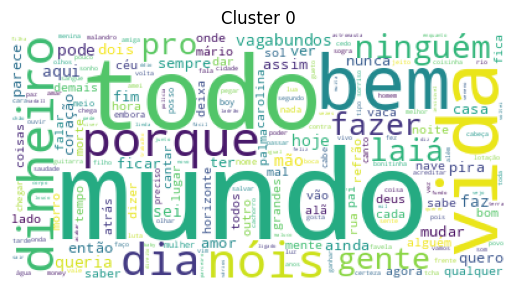

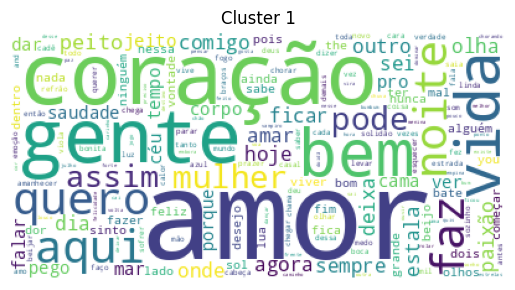

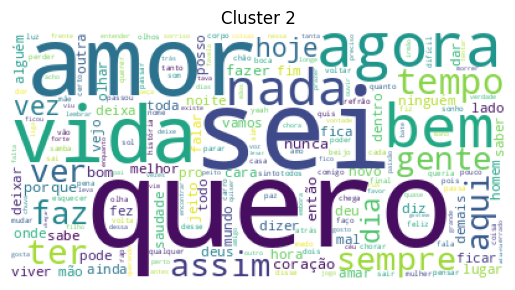

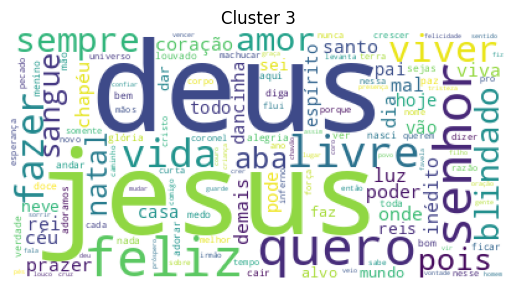

In [20]:
# Exibindo as palavras mais comuns e cada grupo
generate_word_clouds(counting_words(letras,labels_tfidf, 'tfidf_group'))

In [21]:
#Exibindo alguns regristo de um certo grupo
#Escolha um grupo e analise os artistas, letras e gêneros

pd.options.display.max_colwidth = 100
letras.query('tfidf_group == 2')[['SName', 'Lyric', 'Artist', 'Genre']].sample(10)

,SName,Lyric,Artist,Genre
3282,Combinado,"O combinado foi não cobrar nada,. Só viver momentos intensos de puro prazer. Eu fui sincero quan...",Mumuzinho,Samba
3252,Liquido do Amor,refrão. vem conhecer o prazer eu quero nhanha. quero te enlouquecer. procuro a todo o tempo um j...,Mr. Catra,Funk Carioca
2877,Sinal de Fumaça,Você provocou a discussão. Entre o bom senso e o coração. Um tá querendo distância. E o outro tá...,Matheus e Kauan,Sertanejo
2174,Quando A Noite Cai,"Quando a noite cai, eu já sei. Já sei que não vou suportar. Sou capaz de tudo fazer.. Pra reenco...",Kelly Key,Pop
4139,Te Ligo Depois,"Diz que vai deixar de lado. Meu contato. Pra que a noite seja meu lugar. Só você me faz feliz, s...",Rouge,Pop
1370,Divina Luz,Clareou. No terreiro as cabrochas sambando clareou. Quem gritou. Vai correndo buscar a viola meu...,Fundo de Quintal,Samba
2388,Samba da Caixa Preta,"Minha alma chora, vejo o Rio de Janeiro. Rio do desterro, samba, funk, telecoteco e James Brown....",Lobão,Rock
4701,Vamos Beber,"É meia-noite, baby. Sessão vampiro já. Pula a janela e vem. É hora de rodar. A noite chama a gen...",Velhas Virgens,Rock
4667,Teimoso,Não implique por eu ser teimoso. já que a minha teimosia não é como a do burro. que empaca e faz...,Ultraje A Rigor,Rock
803,Coisa de Cinema,Hoje tudo tem que ser legal. E o super-homem que se dane. vai virar noticia de jornal. hoje que ...,Claudinho & Buchecha,Pop


## PPMI (Positive Pontual Multiwise Individual)

Agora vamos trabalhar com um método diferente de vetorização. Vamos calcular o PPMI de cada palavra e depois transformar as letras utilizando os embeddings de cada palavra em cada letra.


1. Utilize um vetorizador para contar cada palavra (bag-of-words) da coluna clean_lyrics do dataframe. Salve o resultado da vetorização na variável X

In [22]:
#Seu código aqui

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(letras['clean_lyrics'])

### Documentos de exemplo:
- 1) "gato preto bebe leite"
- 2) "gato bebe leite"
- 3) "cachorro bebe agua"


<br>

### Palavras únicas que ocorrem nos documentos:

- 'agua', 'bebe', 'cachorro', 'gato', 'leite', 'preto'

<br>

## Verificando as ocorrências:

### Para o Documento 1:

- No documento 1, a palavra agua ocorre 0 vez;
- No documento 1, a palavra bebe ocorre 1 vez;
- No documento 1, a palavra cachorro ocorre 1 vez;
- No documento 1, a palavra gato ocorre 0 vez;
- No documento 1, a palavra leite ocorre 1 vez;
- No documento 1, a palavra preto ocorre 1 vez;

<br>

V1 = Doc1 = [0, 1, 1, 0, 1, 1]

<br>

### Para o Documento 2:

- No documento 2, a palavra agua ocorre 0 vez;
- No documento 2, a palavra bebe ocorre 1 vez;
- No documento 2, a palavra cachorro ocorre 0 vez;
- No documento 2, a palavra gato ocorre 1 vez;
- No documento 2, a palavra leite ocorre 1 vez;
- No documento 2, a palavra preto ocorre 0 vez;

<br>

V2 = Doc2 = [0, 1, 0, 1, 1, 0]

<br>

### Para o Documento 3:

- No documento 3, a palavra agua ocorre 1 vez;
- No documento 3, a palavra bebe ocorre 1 vez;
- No documento 3, a palavra cachorro ocorre 1 vez;
- No documento 3, a palavra gato ocorre 0 vez;
- No documento 3, a palavra leite ocorre 0 vez;
- No documento 3, a palavra preto ocorre 0 vez;

<br>

- V3 = Doc3 = [1, 1, 1, 0, 0, 0]

Unindo os vetores para formar uma matriz:

$$
\begin{array}{c|cccccc}
 & agua & bebe & cachorro & gato & leite & preto \\
\hline
Doc 1 & 0 & 1 & 0 & 1 & 1 & 1 \\
Doc 2 & 0 & 1 & 0 & 1 & 1 & 0 \\
Doc 3 & 1 & 1 & 1 & 0 & 0 & 0 \\
\end{array}
$$



$$
X^T X =
\begin{bmatrix}
0 & 0 & 1 \\
1 & 1 & 1 \\
0 & 0 & 1 \\
1 & 1 & 0 \\
1 & 1 & 0 \\
1 & 0 & 0
\end{bmatrix}
\cdot
\begin{bmatrix}
0 & 1 & 0 & 1 & 1 & 1 \\
0 & 1 & 0 & 1 & 1 & 0 \\
1 & 1 & 1 & 0 & 0 & 0
\end{bmatrix}
=
X^T X =
\begin{bmatrix}
1 & 1 & 1 & 0 & 0 & 0 \\
1 & 3 & 1 & 2 & 2 & 1 \\
1 & 1 & 1 & 0 & 0 & 0 \\
0 & 2 & 0 & 2 & 2 & 1 \\
0 & 2 & 0 & 2 & 2 & 1 \\
0 & 1 & 0 & 1 & 1 & 1
\end{bmatrix}
$$

$$
\begin{array}{c|cccccc}
 & agua & bebe & cachorro & gato & leite & preto \\
\hline
agua     & 1 & 1 & 1 & 0 & 0 & 0 \\
bebe     & 1 & 3 & 1 & 2 & 2 & 1 \\
cachorro & 1 & 1 & 1 & 0 & 0 & 0 \\
gato     & 0 & 2 & 0 & 2 & 2 & 1 \\
leite    & 0 & 2 & 0 & 2 & 2 & 1 \\
preto    & 0 & 1 & 0 & 1 & 1 & 1 \\
\end{array}
$$

Ou seja, agua ocorre com agua uma vez nos documentos, bebe e leite co-ocorrem 2 vezes, observando a linha e coluna.

In [23]:
#Essa etapa está pronta, não é necessário mudá-la. Aqui estamos gerando a matriz de co-ocorrência das palavras
Xc = (X.T @ X).toarray()  # coocorrência entre palavras

2. Invoque a função compute_ppmi_smoothed para calcular o PPMi de cada palavra. Você pode fazer isso passando a variável Xc como argumento do método. Salve o resultado na variável ppmi_matrix

In [24]:
#Seu código aqui
ppmi_df = compute_ppmi_smoothed(Xc)

3. Crie um dataframe chamado ppmi_df. Para essa criação você precisa da variável ppmi_matrix e do nome de cada coluna. Os nomes podem ser obtidos utilizando o vetorizador criado anteriormente e invocando o método get_features_names_out(). A criação pode ser feita utilizando o método pd.Dataframe(seu_dados, index=suas_palavras, columns=suas_palavras)

In [25]:
#Seu código aqui
words = vectorizer.get_feature_names_out()
ppmi_df = pd.DataFrame(Xc, index=words, columns=words)

ppmi_df.head()

,aaa,aaaaaaaaa,aaaaaaah,aaaaah,aaaah,aaahhh,aah,aahh,aahhh,aai,...,ôuôuôu,ôuôô,ôôh,última,últimas,último,única,único,útero,útil
aaa,16,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
aaaaaaaaa,0,81,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
aaaaaaah,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
aaaaah,0,0,0,4,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
aaaah,0,0,0,0,4,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [26]:
#Esse trecho não precisa ser alterado. Estamos apenas liberando espaço na memória
del Xc

4. Complete o método abaixo para que ele seja capaz de transformar cada letra das músicas em sua forma vetorizada utilizando os embeddigns das palavras do dataframe ppmi_df.

In [27]:
#Esse método está parcialmente implementado
def lyric_embeddings_from_ppmi(df, text_column, ppmi_df):

    #Essa variável irá salvar os embeddings de cada letra
    embeddings = []
    words_in_vocab = set(ppmi_df.index)

    for lyric in df[text_column]:

        #1. Para cada letra do dataframe, primeiro separe as palavras pelo espaço

        words = lyric.split()
        temp_vectors = []

        #2. Para cada palavra que foi separada por espaço, busque no dataframe ppmi_df seu embedding e salve-a em um vetor auxiliar
        # Você pode fazer buscar um embedding de uma palavra usando o método .loc[sua_palavra].values do dataframe ppmi_df
        # Lembre que, para cada embedding, você precisa adicioná-lo ao vetor temporário.

        for word in words:
            if word in words_in_vocab:
                temp_vectors.append(ppmi_df.loc[word].values)


        #3. Calcule a média de todos os embeddings salvos no vetor temporário da etapa anterior
        # Você pode fazer isso utilizado a o método np.mean(seu_vetor_de_vetores, axis=0) e salvando o resultado na variável lyric_vector

        if len(temp_vectors) > 0:
            lyric_vector = np.mean(temp_vectors, axis=0)
        else:
            lyric_vector = np.zeros(ppmi_df.shape[1])

        #4. Salvando o embedding de cada letra, ou seja, a versão vetorizada da letra.
        embeddings.append(lyric_vector)

    # Criando um novo DataFrame com as representações e retornando-a
    embedding_df = pd.DataFrame(embeddings, index=df.index)
    return embedding_df

In [28]:
# Essa etapa já está pronta, não é necessário mudá-la. Aqui, passamos nosso dataframe de letras e recebemos um dataframe de embeddings
ppmi_embeddings_df = lyric_embeddings_from_ppmi(letras, 'clean_lyrics', ppmi_df)
ppmi_embeddings_df.head()

,0,1,2,3,4,5,6,7,8,9,...,13877,13878,13879,13880,13881,13882,13883,13884,13885,13886
4656,0.058824,0.926471,0.014706,0.441176,0.117647,0.176471,0.191176,0.191176,0.058824,0.882353,...,0.264706,0.000000,0.117647,1.250000,0.367647,3.661765,0.661765,0.661765,0.132353,0.220588
3659,0.350365,1.839416,0.000000,0.291971,0.729927,0.043796,0.335766,0.467153,0.014599,1.226277,...,0.744526,1.109489,0.189781,0.540146,0.087591,3.116788,2.832117,1.459854,0.350365,0.204380
907,1.027027,1.459459,0.013514,0.675676,0.216216,0.567568,0.202703,0.283784,0.189189,0.243243,...,0.851351,0.378378,0.256757,0.824324,0.175676,3.148649,1.324324,1.121622,0.148649,0.202703
4352,2.321839,2.275862,0.017241,0.459770,0.149425,0.655172,0.264368,0.235632,0.218391,1.034483,...,0.637931,0.413793,0.356322,1.017241,0.080460,2.241379,1.609195,0.925287,0.080460,0.091954
3271,2.290598,1.923077,0.000000,0.410256,0.102564,0.205128,0.059829,0.076923,0.068376,0.000000,...,1.820513,0.153846,0.205128,1.666667,0.358974,3.769231,0.837607,0.692308,0.034188,0.085470


5. Agora, vamos executar o Kmeans como nosso dataframe ppmi_embeddings_df. Você pode ver o exemplo de uso do KMeans na Seção Inicial deste notebook.

- Use k = 4
- Crie um novo objeto do tipo MiniBatchKMeans
- Salve as classificações na variável labels_pmi
- Faça uma nova coluna no dataframe letras (letras['pmi_group']) e atribua labels_pmi

In [29]:
#Seu código aqui
from sklearn.cluster import MiniBatchKMeans

# cria o modelo com k = 4
kmeans = MiniBatchKMeans(n_clusters=4, random_state=42)

# treina e obtém os labels
labels_pmi = kmeans.fit_predict(ppmi_embeddings_df)

# adiciona ao dataframe original
letras['pmi_group'] = labels_pmi

letras.sample(10)

,SName,Lyric,Artist,Songs,Popularity,Genre,Genres,clean_lyrics,tfidf_group,pmi_group
51,Ela Disse-Me Assim (Vá Embora),"Ela disse-me assim. ""Tenha pena de mim. Vá embora!. Ele pode chegar. Vais me prejudicar. Tá na h...",Adriana Calcanhotto,198,5.0,Pop,Pop,disse assim pena embora pode chegar vais prejudicar hora motivo nenhum recusar beijos caí braços...,2,0
4795,O Que É O Que É?,"Todo mundo quer saber bem direitinho. Quem nasceu primeiro, o ovo ou o pintinho. Todo mundo quer...",Xuxa,539,14.1,Pop,Infantil; Pop; Dance; Clássico; Axé; Electronica; Hip Hop; Post-Rock; MPB; Funk; Country; Bossa ...,todo mundo saber bem direitinho nasceu primeiro ovo pintinho todo mundo saber diga eva nasceu co...,0,0
4125,Em Espírito E Em Verdade,"Em espírito, em verdade,. Te adoramos, te adoramos.. Rei dos reis e Senhor,. Te entregamos o nos...",Rosa de Saron,134,8.2,Rock,Gospel/Religioso; Rock; Pop/Rock; Romântico; Rock Alternativo; Axé; Funk; MPB; Blues; Pagode; Ha...,espírito verdade adoramos adoramos rei reis senhor entregamos viver adorar rei reis nasci rei je...,3,0
3484,Nós Fugueta E Mete O Pé,"Eu vou ser sincero,. Eu sou comprometido,. E o que eu posso te dar mulher,. Só um pente escondid...",Os Hawaianos,79,1.5,Funk Carioca,Funk Carioca; Pagode; Electronica; Sertanejo; Axé; Hip Hop; Gospel/Religioso; Forró; Hard Rock; ...,sincero comprometido posso dar mulher pente escondido traição arriscado romance perigo lance pro...,1,2
584,Espaço,Quarto de não dormir. Sala de não estar. Porta de não abrir. Pátio de sufocar. Carta no corredor...,Cássia Eller,141,7.5,Rock,Rock; MPB; Pop/Rock; Pop; Romântico; Samba; Country; Classic Rock; Pagode; Gospel/Religioso; Bla...,quarto dormir sala porta abrir pátio sufocar carta corredor pegar voz gravador quero escutar lua...,0,2
586,Culpa de Estimação,Por onde eu ando. Levo ao meu lado. A minha namorada. Cheirosa e bem tratada. Não sei se o nome ...,Cazuza,123,9.6,Rock,Pop/Rock; MPB; Rock; Romântico; Rock Alternativo; Pop; Black Music; Country; Gospel/Religioso; E...,onde ando levo lado namorada cheirosa bem tratada sei nome eva adão religiosa formação culpa est...,2,0
1344,Desde Já,"Então comece desde ja,pare de falar sobre o que aconteceu entre nós. Então comece a fingir ignor...",Fresno,142,2.2,Rock,Pop/Rock; Emocore; Rock; Pop/Punk; Hardcore; Piano Rock; Rock Alternativo; Romântico; Post-Rock;...,então comece desde pare falar sobre aconteceu então comece fingir ignore fato naquele dia ter si...,2,0
4480,Sou Feliz,"Se paz a mais doce me deres gozar. Se dor a mais forte sofrer. Oh, seja o que for tu me fazes sa...",Thalles Roberto,121,6.8,Pop,Gospel/Religioso; Pop; Black Music; Pop/Rock; Soul Music; Rock; Blues; Jazz; Axé; Hip Hop; Funk;...,paz doce deres gozar dor forte sofrer fazes saber feliz jesus sempre feliz jesus feliz jesus sen...,3,0
3148,Na Chatuba É o Bicho,[Introdução]. Hahaha. Terror(Terror). [Verso]. Oi na Chatuba é o bicho. M.k e o F.b. Relíquia do...,Mc Orelha,16,2.3,Funk Carioca,Funk Carioca; Funk; Rap; Pop/Punk; Pop; Hardcore; Hard Rock; Black Music; Axé,introdução hahaha terror terror verso chatuba bicho relíquia puro proceder família unida guerrei...,2,2
4295,Os Homens Das Cavernas,Nós somos a molambeira. A vida nos trata a cacete. O que é morada eu não sei. Se tive já esqueci...,Skank,139,12.3,Rock,Pop/Rock; Rock; Pop; Rock Alternativo; MPB; Romântico; Reggae; Ska; Blues; Gospel/Religioso; Tri...,molambeira vida trata cacete morada sei esqueci aqui debaixo ponte final avenida senhor presiden...,2,2


6. A partir daqui, não é necessário nenhuma implementação. Apenas execute as células para realizar análises sobre os resultados.

In [30]:
#Verificando a quantidade de letras por grupo.
letras['pmi_group'].value_counts()

,count
pmi_group,
0,378
2,329
1,190
3,103


In [31]:
#Listando os cantores presentes em cada grupo e a quantidade de músicas dele que faz parte do grupo
for g in range(0, k):
  print('\n-----\nGRUPO {}:'.format(g))
  print(letras.query('pmi_group ==  {}'.format(g))['Artist'].value_counts()[0:10])
  print('-----')


-----
GRUPO 0:
Artist
Xuxa                   5
Gian & Giovani         5
Wanessa Camargo        5
Mart'nália             4
Grupo Revelação        4
Fernando e Sorocaba    4
Chrystian e Ralf       4
Kelly Key              4
Capital Inicial        4
Gino & Geno            4
Name: count, dtype: int64
-----

-----
GRUPO 1:
Artist
Raça Negra              4
Gian & Giovani          4
Claudinho & Buchecha    4
Anitta                  3
Rodriguinho             3
Felipe Araújo           3
Ana Carolina            3
Ivete Sangalo           3
Cine                    3
Nosso Sentimento        3
Name: count, dtype: int64
-----

-----
GRUPO 2:
Artist
Hungria                     7
Racionais Mc's              6
Mag                         6
Mc Pocahontas               5
Mc Neguinho do Kaxeta       5
Tião Carreiro e Pardinho    5
Adoniran Barbosa            5
Tonico e Tinoco             5
Facção Central              5
Ao Cubo                     5
Name: count, dtype: int64
-----

-----
GRUPO 3:
Artist
Ra

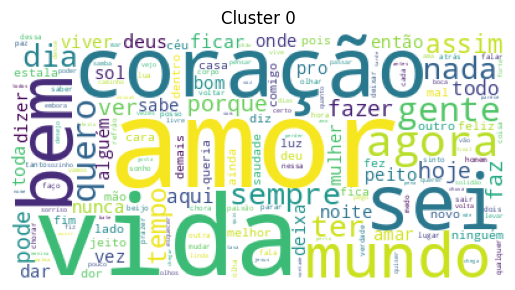

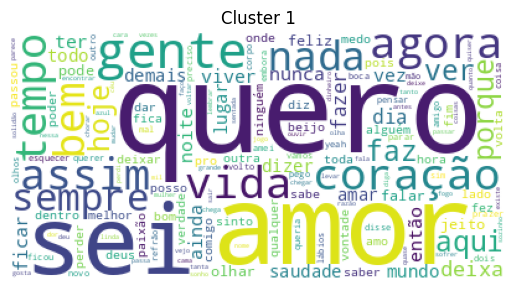

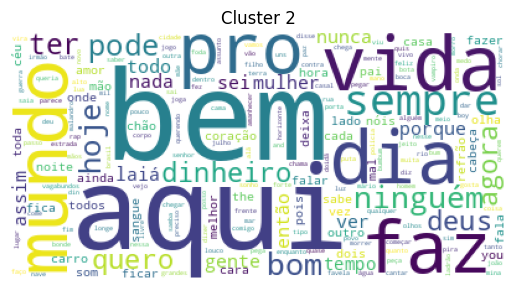

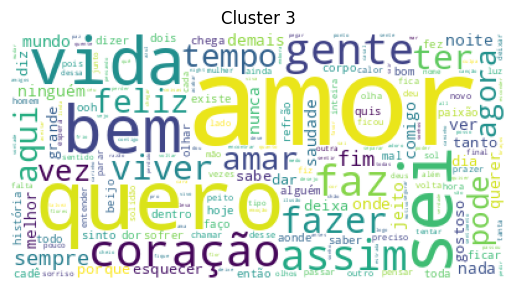

In [32]:
generate_word_clouds(counting_words(letras,labels_pmi, 'pmi_group'))

In [33]:
#Exibindo alguns regristo de um certo grupo
#Escolha um grupo e analise os artistas, letras e gêneros

pd.options.display.max_colwidth = 100
letras.query('pmi_group == 3')[['SName', 'Lyric', 'Artist', 'Genre']].sample(10)

,SName,Lyric,Artist,Genre
3435,O Teu Amor,Quantas vezes olhei pra trás. Tentando achar o que perdi. Confuso em meio a tantos erros. Você n...,Oficina G3,Rock
2515,Modo Avião,"Ah, é melhor deixar o amor. Em modo avião. Dá pra perceber. Que os nossos planos, não tem nada a...",Ludmilla,Pop
90,Mais Além,Atende aí o celular. O prazer que eu sinto só de imaginar. Que logo mais a noite estarei com voc...,Alexandre Pires,Samba
1513,Proposta,Vou me dar inteiro pra esta mulher. Vou lhe dar a vida se ela quiser. Quero ser prazer na hora d...,Gilberto e Gilmar,Sertanejo
429,Xodó da Mãe,Xodó da Mãe. Quero ser livre e sincero. Sem falsa crença ou prisão. Se eu amar quem não quero. É...,Bom Gosto,Samba
4017,A Força do Amor,Abriu minha visão o jeito do amor. Tocando o pé no chão alcança as estrelas. Tem poder de mover ...,Rick & Renner,Sertanejo
2031,Mal do Amor (bichinho),Por que um homem se apaixona e padece. Por uma mulher que às vezes não merece?. Nesta vida nenhu...,João Paulo e Daniel,Sertanejo
3011,Cinderela (Mc Bella com Mc Gui),[Mc Gui]. Estilo Cinderela numa passarela. Dentro da favela. Perguntei o nome dela. Ela disse qu...,Mc Gui,Pop
1183,"Masculino, Feminino","Masculino, feminino. Robrto Carlos - Erasmo Carlos. . Já são seis horas, meu bem. Vire o relógio...",Erasmo Carlos,Rock
4504,De Todas As Coisas,"Não quero nada. Menos que nada. Nada de nada. Me falta em você, eh-eh-eh. Não quero pressa. Meno...",Tiago Iorc,Pop


## Perguntas sobre o PMI

Responda cada perguntando apresentando uma justificativa

1. Considerando os artistas de cada grupo, é possível verificar alguma conexão entre eles? (Ex: gênero, estilo de música, temas abordados)

`Em geral, sim. No caso do Cluster 2, a nuvem mostra palavras como "vida", "mundo", "Deus", "amor", "tempo", "sempre", "hoje", ... o que pode ser musicas relacionadas e temas reflexivos, como religiosa, gospel ou mpb. Também é possivel identificar uma mistura de gêneros como sertanejo, romântico e amor em alguns clusters.`

2. Considerando as nuvens de palavras de cada grupo, argumente se existe um grupo bem definido ou se não existe uma definição clara sobre que tipo de música (tema) cada grupo tem.

`Algumas palavras em cada clusters são muito genéricas e é dificil saber bem o tipo de música de cada grupo, pois há uma mistura de vários gêneros musicais em cada cluster.`

3. De maneira geral, você acha que os resultados do PPMI são mais consistentes que os do TFIDF?

`O TF-IDF foi muito melhor que o PPMI, tanto é que é possivel identificar muito bem s clusters gospeis (cluster 3), de sertanejo (cluster 0) e de amor(cluster 1). Portanto, o TF-IDF foi melhor, pois as palavras mais importantes no documento são destacadas, penalizando palavras muito frequentes no corpus e consegue distinguir bem os documentos. Já o PPMI mede a associação entre as palavras, como coocorrencia e destaca palavras que aparecem juntas com frequencia. Portanto, o TF-IDF tende a ser mais consistente para clusters de documentos.`

# Word2Vec

Agora vamos trabalhar com o Word2Vec. Primeiramente vamos treinar os embeddings considerando todas as letras do nosso dataset. Em seguida, vamos vetorizar essas letras utilizando os embeddings das palavras de cada letra. Em seguida, vamos aplicar o KMeans e analisar os grupos.

1. Inicialmente, precisamos quebrar cada letra do nosso dataset em uma lista de palavras. Isso deve ser feito para cada letra. O resultado deve ser um vetor de vetores, em que cada subvetor é o conjunto de palavras da letra atual. Lembre-se que você deve considerar as letras que estão na coluna 'clean_lyric' do dataframe.

In [34]:
#Seu código aqui

sentences = [lyric.split() for lyric in letras['clean_lyrics']]

2. Chame a classe Word2Vec() passando para ela o vetor de letras que estão separadas por espaço. Além disso, utilize os seguintes parâmetros:

- vector_size=100,  # tamanho dos vetores
- window=5,
- min_count=2,
- workers=4,
- epochs=15,
- sg=1


- Salve o modelo na variável w2v_model

In [35]:
# Treina o modelo Word2Vec
# Seu código aqui

w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=15,
    sg=1
)

w2v_model.wv['amor']

array([ 0.14737777,  0.00713737,  0.29075032, -0.16413139, -0.17690858,
       -0.49451637,  0.12191242,  0.9916541 , -0.61480445, -0.28187466,
        0.25602418, -0.8839417 , -0.29180577, -0.24829991,  0.07731016,
       -0.22776732, -0.10308623, -0.02969531, -0.40123016, -0.89546514,
        0.22148871,  0.5739791 ,  0.47785854, -0.4345663 ,  0.52815366,
       -0.18922365,  0.07125064, -0.00938128, -0.446071  , -0.5581537 ,
       -0.16815346,  0.5859603 ,  0.30067867, -0.3962764 ,  0.02016193,
        0.25851098, -0.34428185, -0.6012404 ,  0.02003213,  0.1479151 ,
       -0.33705238, -0.45759147, -0.31610948, -0.47221643, -0.3092326 ,
        0.2534939 , -0.50268483, -0.38584802,  0.4295016 ,  0.17871931,
        0.14608628,  0.10705913,  0.09255584,  0.40814593,  0.18003042,
       -0.4685471 , -0.08645117, -0.08994023, -0.15599099, -0.03196718,
        0.02057191, -0.0287233 ,  0.03347807, -0.2201737 , -0.04830037,
        0.64211816, -0.2524203 ,  0.37610775, -0.86587167,  0.63

3. Complete o método abaixo para que ele seja capaz de transformar cada letra das músicas em sua forma vetorizada utilizando os embeddigns das palavras que você pode obter do modelo w2v_model.

In [36]:
#Este método está parcialmente completo. Ele tem algumas similaridades com o método de
def lyric_embeddings_from_w2v(df, text_column, w2v_model):

    #Aqui será armazenando o embedding final de cada letra.
    embeddings = []
    vocab = w2v_model.wv.key_to_index

    for lyric in df[text_column]:

        #1. Para cada letra do dataframe, primeiro separe as palavras pelo espaço

        words = lyric.split()
        temp_vectors = []

        #2. Para cada palavra que foi separada por espaço, busque no w2v_model seu embedding e salve-a em um vetor auxiliar
        # Você pode fazer buscar um embedding de uma palavra usando o método w2v_model.wv[sua_palavra]
        # Lembre que, para cada embedding, você precisa adicioná-lo ao vetor temporário.

        for word in words:
            if word in vocab:
                temp_vectors.append(w2v_model.wv[word])

        #3. Calcule a média de todos os embeddings salvos no vetor temporário da etapa anterior
        # Você pode fazer isso utilizado a o método np.mean(seu_vetor_de_vetores, axis=0) e salvando o resultado na variável lyric_vector

        if len(temp_vectors) > 0:
            lyric_vector = np.mean(temp_vectors, axis=0)
        else:
            # caso nenhuma palavra esteja no vocabulário
            lyric_vector = np.zeros(w2v_model.vector_size)

        #4. Salvando o embedding de cada letra, ou seja, a versão vetorizada da letra.
        embeddings.append(lyric_vector)

    # Cria um DataFrame com os embeddings
    embedding_df = pd.DataFrame(embeddings, index=df.index)
    return embedding_df

In [37]:
# Esta parte está pronta, não é necessário alterá-la
w2v_embeddings_df = lyric_embeddings_from_w2v(letras, 'clean_lyrics', w2v_model)
w2v_embeddings_df.head()

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
4656,0.029653,0.023425,-0.119036,-0.101350,-0.008116,-0.251070,0.141362,0.404434,-0.022208,0.023442,...,0.112060,0.100788,0.158040,0.251904,0.092849,0.143407,0.268351,-0.144372,0.052342,0.040084
3659,-0.136617,0.405845,-0.159935,-0.197465,0.197619,-0.172765,-0.013877,0.164404,-0.048522,0.020682,...,0.232258,-0.111921,0.203308,0.149986,0.043035,0.159968,0.073620,-0.154242,0.039145,-0.250651
907,-0.062797,0.281664,-0.162831,-0.101273,0.130603,-0.220820,0.069426,0.296265,-0.056851,-0.049113,...,0.159268,0.052405,0.165815,0.283488,0.058779,0.252095,0.165882,-0.290030,0.217233,0.009897
4352,0.003698,0.136696,-0.141545,-0.204065,0.042478,-0.220111,0.091746,0.408859,-0.127197,0.060411,...,0.226257,0.033296,0.262150,-0.057797,0.122248,0.244968,0.157863,-0.231818,0.163980,-0.096948
3271,0.029284,0.095382,-0.081846,-0.182736,0.107436,-0.222562,0.189524,0.452232,-0.134058,0.188107,...,0.195037,-0.015347,0.131279,-0.051521,0.020581,0.311968,0.166763,-0.257487,0.133010,-0.214422


4. Agora, vamos executar o Kmeans como nosso dataframe w2v_embeddings_df. Você pode ver o exemplo de uso do KMeans na Seção Inicial deste notebook.
- Use k = 4
- Crie um novo objeto do tipo MiniBatchKMeans()
- Salve as classificações na variável labels_w2v
- Faça uma nova coluna no dataframe letras (letras['w2v_group']) e atribua labels_w2v

In [38]:
#Seu código aqui

kmeans = MiniBatchKMeans(n_clusters=4, random_state=42)

# treina e obtém os rótulos
labels_w2v = kmeans.fit_predict(w2v_embeddings_df)
letras['w2v_group'] = labels_w2v

letras.sample(10)

,SName,Lyric,Artist,Songs,Popularity,Genre,Genres,clean_lyrics,tfidf_group,pmi_group,w2v_group
3526,Quero Amar,"OOuuuh, oooooh,ooohh. Junto com você eu descobri o amor. o mundo era escuro agora é cheio de cor...",Pacificadores,98,2.2,Hip Hop,Hip Hop; Rap; Romântico; Funk; Black Music; Electronica; Pop; Rock; Axé; Reggae; Sertanejo; Gosp...,oouuuh oooooh ooohh junto descobri amor mundo escuro agora cheio cor vida sentido faz comigo que...,1,3,3
2092,Fica Combinado (com Marcos e Fernando),Não faz charme. Não me esnoba. Eu tirei dez na sua prova de sedução. Já li mais de um milhão de ...,Jorge e Mateus,238,34.7,Sertanejo,Romântico; Sertanejo; House; Axé; Country; Gospel/Religioso; Pop; Funk; Funk Carioca; Pagode; Fo...,faz charme esnoba tirei dez prova sedução milhão palavras olhos percebi calor saindo poros preci...,2,0,2
305,Só As Mães SÃo Felizes,Você nunca varou. A Duvivier às cinco. Nem levou um susto. Saindo do Val improviso. Era quase me...,Barão Vermelho,160,3.8,Rock,Rock; Pop/Rock; MPB; Romântico; Rock Alternativo; Forró; Trance; Trilha Sonora; K-Pop/K-Rock; In...,nunca varou duvivier cinco levou susto saindo val improviso quase meio dia lado escuro vida nunc...,2,2,0
3413,Cruz de Tecido,Olhos em pânico refletem as chamas. Que cruzam o céu da avenida. De encontro a estrutura de aço ...,O Rappa,97,10.2,Rock,Reggae; Rap; Rock; Pop/Rock; Black Music; Funk Carioca; Funk; Hip Hop; Grunge; Piano Rock; Rock ...,olhos pânico refletem chamas cruzam céu avenida encontro estrutura aço concreto muitas almas per...,1,2,0
1049,Sangrando,"Quando eu soltar a minha voz. Por favor, entenda. Que palavra por palavra. Eis aqui uma pessoa s...",Diogo Nogueira,120,4.1,Samba,Samba; MPB; Romântico; Samba Enredo; Pagode; Velha Guarda; Funk; Grunge; Sertanejo; Industrial; ...,soltar voz favor entenda palavra palavra eis aqui pessoa entregando coração boca peito aberto sa...,1,2,3
3392,Loucura de Amor,"Preciso te contar o que esta acontecendo comigo. Estou amando uma mulher comprometida, que casti...",Nosso Sentimento,101,4.9,Samba,Romântico; Samba; Pagode; Trilha Sonora; Funk; Funk Carioca; Country; Grunge; Surf Music; House;...,preciso contar acontecendo comigo amando mulher comprometida castigo aqui escutar dar ombro amig...,1,1,2
3618,História de Uma Gata,"O meu mundo era o apartamento. Detefon, almofada e trato. Todo dia filé-mignon. Ou mesmo um bom ...",Pedra Letícia,39,1.1,Rock,Pop/Rock; Rock; Pop; Rock Alternativo; Hard Rock; Dance; Classic Rock; Tecnopop; Forró; Bossa Nova,mundo apartamento detefon almofada trato todo dia filé mignon bom filé gato diziam todo momento ...,0,2,0
3839,Palhas do Coqueiro,"Pá Pá Pá Pá x4. Debaixo lá das palhas do coqueiro. É onde eu estou a lhe esperar(a lhe esperar, ...",Raimundos,121,4.2,Rock,Punk Rock; Hardcore; Rock; Pop/Rock; Hard Rock; Metal; Heavy Metal; Pós-Punk; Rock Alternativo; ...,debaixo palhas coqueiro onde esperar esperar esperar fico esperando ali sozinho ter carinho ning...,2,0,2
3825,A História,"João era um pivete com pensamentos subliminares, queria ter dinheiro jatinho para viajar nos are...",Racionais Mc's,81,25.5,Hip Hop,Hip Hop; Rap; Black Music; Funk; Gospel/Religioso; Funk Carioca; Blues; Regional; Reggae; Axé; C...,joão pivete pensamentos subliminares queria ter dinheiro jatinho viajar ares lugar onte lindo fa...,0,2,0
2574,Rebaixei,"Haha,ai moleque gostou da carreta né,tira o olho vai,vai sente a pressão agora eu quero ver.... ...",Mag,63,2.3,Hip Hop,Hip Hop; Rap; Black Music; Funk; Pagode; Romântico; Gospel/Religioso; Gótico; Forró; Axé; Funk C...,haha moleque gostou carreta tira olho sente pressão agora quero ver cortei molas rebaixei joguei...,2,2,1


5. A partir daqui, não é necessário nenhuma implementação. Apenas execute as células para realizar análises sobre os resultados.

In [39]:
#Verificando a quantidade de letras por grupo.
letras['w2v_group'].value_counts()

,count
w2v_group,
3,355
0,351
2,197
1,97


In [40]:
#Listando os cantores presentes em cada grupo e a quantidade de músicas dele que faz parte do grupo
for g in range(0, k):
  print('\n-----\nGRUPO {}:'.format(g))
  print(letras.query('w2v_group ==  {}'.format(g))['Artist'].value_counts()[0:10])
  print('-----')


-----
GRUPO 0:
Artist
Gabriel O Pensador    7
Projota               6
Chico Buarque         6
Mc Pocahontas         6
Arlindo Cruz          6
Racionais Mc's        6
Hungria               6
Karol Conka           5
Realidade Cruel       4
Tonico e Tinoco       4
Name: count, dtype: int64
-----

-----
GRUPO 1:
Artist
Bezerra da Silva        4
Mag                     4
Os Hawaianos            3
Gaiola Das Popozudas    3
Mc Gui                  2
Seu Jorge               2
Beth Carvalho           2
Latino                  2
Kleiton e Kledir        2
Ultraje A Rigor         2
Name: count, dtype: int64
-----

-----
GRUPO 2:
Artist
Lucas Lucco        5
Kelly Key          5
Ludmilla           4
Rodriguinho        4
Manu Gavassi       4
Fresno             3
Los Hermanos       3
Grupo Revelação    3
Paulo Ricardo      3
Anavitória         3
Name: count, dtype: int64
-----

-----
GRUPO 3:
Artist
Paulo Ricardo           7
Gian & Giovani          7
RPM                     6
Claudinho & Buchecha    

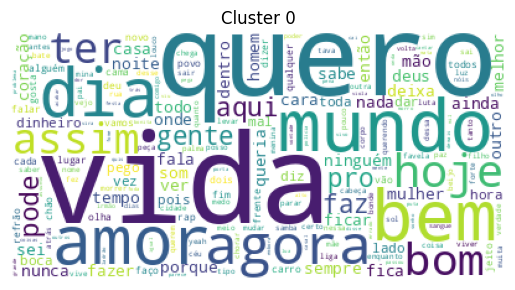

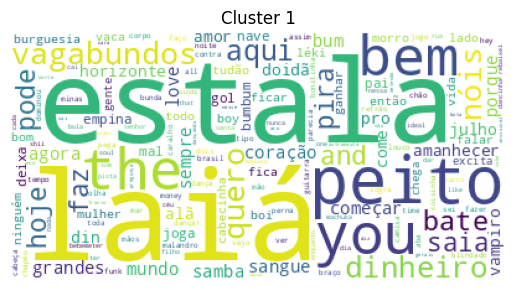

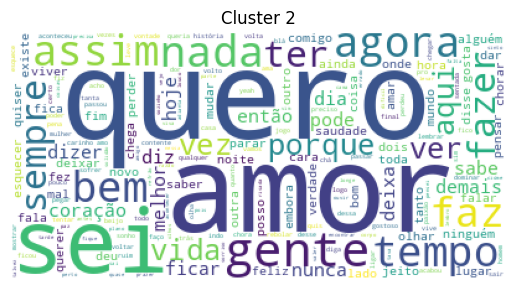

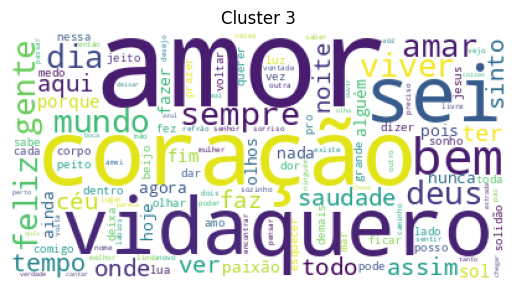

In [41]:
generate_word_clouds(counting_words(letras,labels_w2v, 'w2v_group'))

## Perguntas sobre o Word2Vec
Responda cada perguntando apresentando uma justificativa

1. Considerando os artistas de cada grupo, é possível verificar alguma conexão entre eles? (Ex: gênero, estilo de música, temas abordados)

``

2. Considerando as nuvens de palavras de cada grupo, argumente se existe um grupo bem definido ou se não existe uma definição clara sobre que tipo de música (tema) cada grupo tem.

3. De maneira geral, você acha que os resultados com o Word2Vec são mais consistentes que os dos métodos anteriores?

### Grupo 0

- Gabriel O Pensador
- Projota
- Racionais Mc's
- Karol Conka
- Hungria

Identificquei relações próximas como rap, hip-hop, música urbana com letras com crítica social, cotidiano e realidade urbana, mas cantores como Chico Buarque e Tonico e Tinoco fogem um pouco. Mas em geral está bem coerente.


### Grupo 1

Artistas como:
- Bezerra da Silva
- Os Hawaianos
- Gaiola Das Popozudas
- Latino

Identifiquei relações como Funk, samba e música popular.


### Grupo 2

Artistas como:
- Lucas Lucco
- Ludmilla
- Fresno
- Los Hermanos
- Anavitória

Identifiquei temas próximos como, pop, romântico, jovem
e letras com foco em amor, sentimentos e relações.


### Grupo 3

Artistas como:
- Gian & Giovani
- Sandy
- Alexandre Pires
- Thalles Roberto

Com uma conexão mais emocional e temática do que de gênero.


Eu considero que o modelo no Word2Vec, cada grupo está bem definido, até um pouco melhor do que o TF-IDF (que também foi ótimo), mas que os clusteres estão bem definidos, mas o Word2Vec está misturando generos.